In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
plt.style.use('ggplot')
sns.set_palette('husl')

print('Imports OK')

Imports OK


In [7]:
DATA_PATH = 'online_retail_II.xlsx'
PICKLE_PATH = 'online_retail.pkl'

if Path(PICKLE_PATH).exists():
    df = pd.read_pickle(PICKLE_PATH)
    print('Cargado desde pickle')
else:
    xl = pd.ExcelFile(DATA_PATH)
    df = pd.concat(
        [pd.read_excel(DATA_PATH, sheet_name=s) for s in xl.sheet_names],
        ignore_index=True
    )
    df.to_pickle(PICKLE_PATH)
    print('Cargado desde Excel y guardado en pickle')

print(f'Filas: {len(df):,} | Columnas: {len(df.columns)}')
df.head()

Cargado desde pickle
Filas: 1,067,371 | Columnas: 8


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,"13,085.00",United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,"13,085.00",United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,"13,085.00",United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,"13,085.00",United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,"13,085.00",United Kingdom


In [8]:
# ---- Inspección general ----
print(f'Filas: {len(df):,}')
print(f'Columnas: {len(df.columns)}')
print(f'\nRango temporal:')
print(f'  Desde: {df["InvoiceDate"].min()}')
print(f'  Hasta: {df["InvoiceDate"].max()}')
print(f'  Duración: {(df["InvoiceDate"].max() - df["InvoiceDate"].min()).days} días')
print(f'\nTipos de datos:')
print(df.dtypes)

Filas: 1,067,371
Columnas: 8

Rango temporal:
  Desde: 2009-12-01 07:45:00
  Hasta: 2011-12-09 12:50:00
  Duración: 738 días

Tipos de datos:
Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
Price                 float64
Customer ID           float64
Country                object
dtype: object


In [9]:
# ---- Describe ----
df.describe(include='all').T


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
Invoice,"1,067,371.00","53,628.00","537,434.00","1,350.00",NaN,NaN,NaN,NaN,NaN,NaN,NaN
StockCode,1067371,5305,85123A,5829,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Description,1062989,5698,WHITE HANGING HEART T-LIGHT HOLDER,5918,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Quantity,"1,067,371.00",NaN,NaN,NaN,9.94,"-80,995.00",1.00,3.00,10.00,"80,995.00",172.71
InvoiceDate,1067371,NaN,NaN,NaN,2011-01-02 21:13:55.394028544,2009-12-01 07:45:00,2010-07-09 09:46:00,2010-12-07 15:28:00,2011-07-22 10:23:00,2011-12-09 12:50:00,NaN
Price,"1,067,371.00",NaN,NaN,NaN,4.65,"-53,594.36",1.25,2.10,4.15,"38,970.00",123.55
Customer ID,"824,364.00",NaN,NaN,NaN,"15,324.64","12,346.00","13,975.00","15,255.00","16,797.00","18,287.00","1,697.46"
Country,1067371,43,United Kingdom,981330,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
# ---- Nulos ----
nulos = df.isnull().sum()
nulos_pct = (df.isnull().sum() / len(df) * 100).round(2)
pd.DataFrame({'Nulos': nulos, '% Nulos': nulos_pct})

,Nulos,% Nulos
Invoice,0,0.00
StockCode,0,0.00
Description,4382,0.41
Quantity,0,0.00
InvoiceDate,0,0.00
Price,0,0.00
Customer ID,243007,22.77
Country,0,0.00


In [11]:
# ---- Duplicados ----
dup_total = df.duplicated().sum()
print(f'Filas duplicadas exactas: {dup_total:,} ({dup_total/len(df)*100:.2f}%)')
df[df.duplicated(keep=False)].sort_values(list(df.columns)).head(10)

Filas duplicadas exactas: 34,335 (3.22%)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
379,489517,21491,SET OF THREE VINTAGE GIFT WRAPS,1,2009-12-01 11:34:00,1.95,"16,329.00",United Kingdom
391,489517,21491,SET OF THREE VINTAGE GIFT WRAPS,1,2009-12-01 11:34:00,1.95,"16,329.00",United Kingdom
365,489517,21821,GLITTER STAR GARLAND WITH BELLS,1,2009-12-01 11:34:00,3.75,"16,329.00",United Kingdom
386,489517,21821,GLITTER STAR GARLAND WITH BELLS,1,2009-12-01 11:34:00,3.75,"16,329.00",United Kingdom
363,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,"16,329.00",United Kingdom
371,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,"16,329.00",United Kingdom
394,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,"16,329.00",United Kingdom
362,489517,21913,VINTAGE SEASIDE JIGSAW PUZZLES,1,2009-12-01 11:34:00,3.75,"16,329.00",United Kingdom
385,489517,21913,VINTAGE SEASIDE JIGSAW PUZZLES,1,2009-12-01 11:34:00,3.75,"16,329.00",United Kingdom
368,489517,22130,PARTY CONE CHRISTMAS DECORATION,6,2009-12-01 11:34:00,0.85,"16,329.00",United Kingdom


In [12]:
# ---- Cancelaciones (Invoice empieza por 'C') ----
df['is_cancellation'] = df['Invoice'].astype(str).str.startswith('C')
n_cancel = df['is_cancellation'].sum()
print(f'Líneas de cancelación: {n_cancel:,} ({n_cancel/len(df)*100:.2f}%)')

# Comprobamos que en las cancelaciones la Quantity es negativa
print('\nQuantity en cancelaciones:')
print(df.loc[df['is_cancellation'], 'Quantity'].describe())

print('\nQuantity en no-cancelaciones:')
print(df.loc[~df['is_cancellation'], 'Quantity'].describe())

Líneas de cancelación: 19,494 (1.83%)

Quantity en cancelaciones:
count    19,494.00
mean        -25.19
std         805.10
min     -80,995.00
25%          -6.00
50%          -2.00
75%          -1.00
max           1.00
Name: Quantity, dtype: float64

Quantity en no-cancelaciones:
count   1,047,877.00
mean           10.59
std           135.28
min        -9,600.00
25%             1.00
50%             3.00
75%            10.00
max        80,995.00
Name: Quantity, dtype: float64


In [13]:
# ---- Cantidades negativas que NO son cancelaciones formales ----
neg_no_cancel = df[(df['Quantity'] < 0) & (~df['is_cancellation'])]
print(f'Filas con Quantity < 0 sin ser cancelación formal: {len(neg_no_cancel):,}')
print(f'\nEjemplos:')
print(neg_no_cancel[['Invoice', 'StockCode', 'Description', 'Quantity', 'Price', 'Customer ID']].head(15))


Filas con Quantity < 0 sin ser cancelación formal: 3,457

Ejemplos:
     Invoice StockCode      Description  Quantity  Price  Customer ID
263   489464     21733     85123a mixed       -96   0.00          NaN
283   489463     71477            short      -240   0.00          NaN
284   489467    85123A      21733 mixed      -192   0.00          NaN
470   489521     21646              NaN       -50   0.00          NaN
3114  489655     20683              NaN       -44   0.00          NaN
3162  489660     35956             lost     -1043   0.00          NaN
3168  489663    35605A          damages      -117   0.00          NaN
4296  489806     18010              NaN      -770   0.00          NaN
4538  489820     21133  invcd as 84879?      -720   0.00          NaN
4566  489821    85049G              NaN      -240   0.00          NaN
6556  489899   79323GR     sold as gold      -954   0.00          NaN
6576  489901     21098              NaN      -200   0.00          NaN
6911  490007     84347

In [14]:
# ---- StockCodes que no son productos reales ----
stock_codes_unicos = df['StockCode'].astype(str).unique()
codigos_raros = [c for c in stock_codes_unicos if not c[:5].isdigit()]
print(f'StockCodes "raros" (no empiezan con 5 dígitos): {len(codigos_raros)}')
print(f'\nEjemplos:')
for c in sorted(codigos_raros)[:30]:
    desc = df.loc[df['StockCode'] == c, 'Description'].dropna().unique()
    desc_sample = desc[0] if len(desc) > 0 else '(sin descripción)'
    n = (df['StockCode'] == c).sum()
    print(f'  {c:15s}  n={n:6d}  → {desc_sample}')

StockCodes "raros" (no empiezan con 5 dígitos): 62

Ejemplos:
  ADJUST           n=    67  → Adjustment by john on 26/01/2010 16
  ADJUST2          n=     3  → Adjustment by Peter on Jun 25 2010 
  AMAZONFEE        n=    43  → AMAZON FEE
  B                n=     6  → Adjust bad debt
  BANK CHARGES     n=   102  →  Bank Charges
  C2               n=   282  → CARRIAGE
  C3               n=     1  → (sin descripción)
  CRUK             n=    16  → CRUK Commission
  D                n=   177  → Discount
  DCGS0003         n=    14  → BOXED GLASS ASHTRAY
  DCGS0004         n=     5  → HAYNES CAMPER SHOULDER BAG
  DCGS0006         n=     1  → (sin descripción)
  DCGS0016         n=     1  → (sin descripción)
  DCGS0027         n=     1  → (sin descripción)
  DCGS0036         n=     1  → (sin descripción)
  DCGS0037         n=     2  → KEY-RING CORKSCREW
  DCGS0039         n=     1  → (sin descripción)
  DCGS0041         n=     1  → HAYNES MINI-COOPER PLAYING CARDS
  DCGS0044         n=     

In [15]:
# ---- Ver los 62 stock codes raros completos ----
for c in sorted(codigos_raros):
    desc = df.loc[df['StockCode'] == c, 'Description'].dropna().unique()
    desc_sample = desc[0] if len(desc) > 0 else '(sin descripción)'
    n = (df['StockCode'] == c).sum()
    print(f'  {c:15s}  n={n:6d}  → {desc_sample}')

  ADJUST           n=    67  → Adjustment by john on 26/01/2010 16
  ADJUST2          n=     3  → Adjustment by Peter on Jun 25 2010 
  AMAZONFEE        n=    43  → AMAZON FEE
  B                n=     6  → Adjust bad debt
  BANK CHARGES     n=   102  →  Bank Charges
  C2               n=   282  → CARRIAGE
  C3               n=     1  → (sin descripción)
  CRUK             n=    16  → CRUK Commission
  D                n=   177  → Discount
  DCGS0003         n=    14  → BOXED GLASS ASHTRAY
  DCGS0004         n=     5  → HAYNES CAMPER SHOULDER BAG
  DCGS0006         n=     1  → (sin descripción)
  DCGS0016         n=     1  → (sin descripción)
  DCGS0027         n=     1  → (sin descripción)
  DCGS0036         n=     1  → (sin descripción)
  DCGS0037         n=     2  → KEY-RING CORKSCREW
  DCGS0039         n=     1  → (sin descripción)
  DCGS0041         n=     1  → HAYNES MINI-COOPER PLAYING CARDS
  DCGS0044         n=     1  → HANDZ-OFF CAR FRESHENER
  DCGS0053         n=     1  → (s

In [16]:
# ---- Revenue por línea ----
df['Revenue'] = df['Quantity'] * df['Price']
print(f'Revenue total bruto: £{df["Revenue"].sum():,.0f}')
print(f'Revenue total sin cancelaciones: £{df.loc[~df["is_cancellation"], "Revenue"].sum():,.0f}')
print(f'\nDistribución del revenue por línea:')
print(df['Revenue'].describe())

Revenue total bruto: £19,287,251
Revenue total sin cancelaciones: £20,813,918

Distribución del revenue por línea:
count   1,067,371.00
mean           18.07
std           292.42
min      -168,469.60
25%             3.75
50%             9.90
75%            17.70
max       168,469.60
Name: Revenue, dtype: float64


In [17]:
# ---- Revenue por factura (no por línea) ----
revenue_por_factura = df.loc[~df['is_cancellation']].groupby('Invoice')['Revenue'].sum()
print(f'Número de facturas (sin cancelaciones): {len(revenue_por_factura):,}')
print(f'\nDistribución del ticket por factura:')
print(revenue_por_factura.describe())

Número de facturas (sin cancelaciones): 45,336

Distribución del ticket por factura:
count    45,336.00
mean        459.10
std       1,487.14
min     -53,594.36
25%         104.55
50%         263.54
75%         459.64
max     168,469.60
Name: Revenue, dtype: float64


## Visualización 1: Evolución temporal del revenue

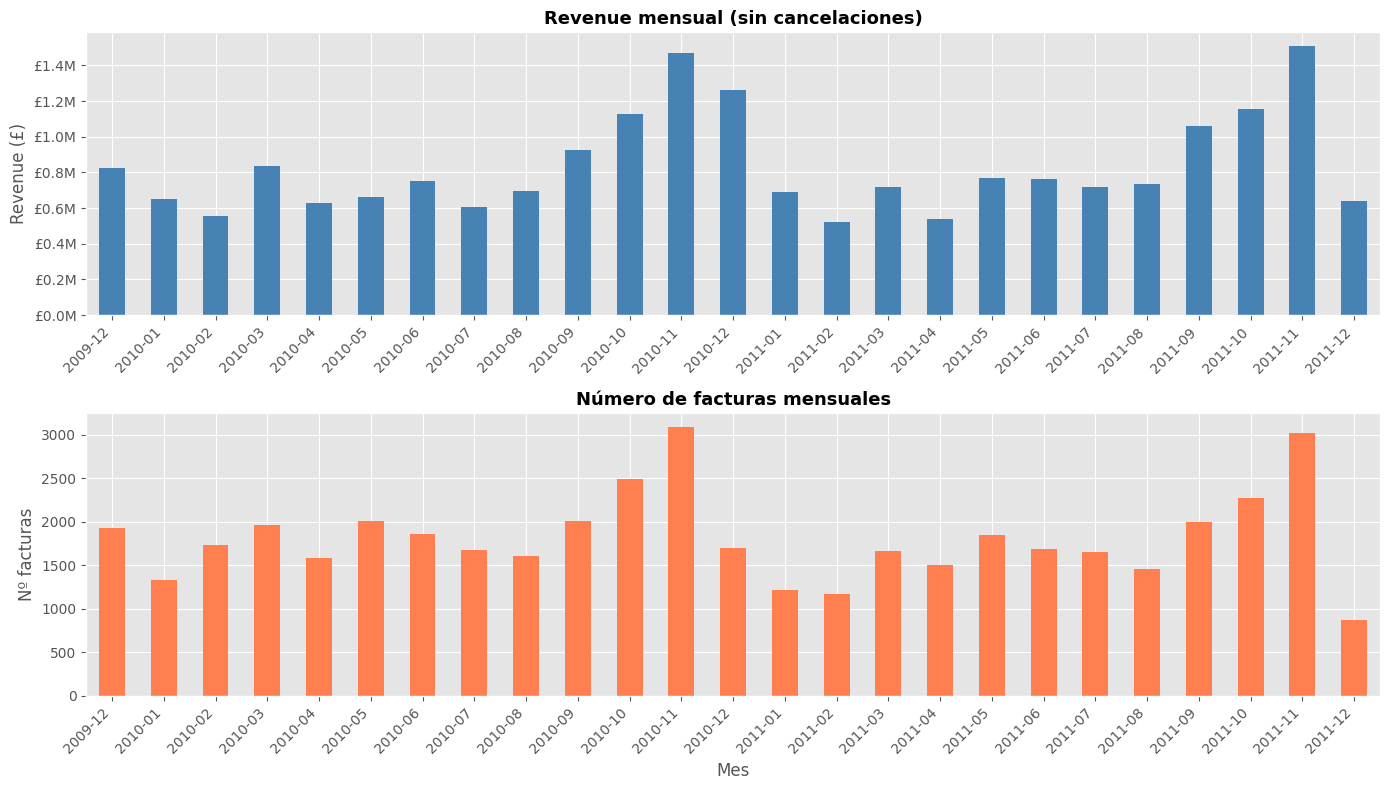

In [18]:
# ---- Evolución temporal: revenue mensual ----
df_clean = df.loc[~df['is_cancellation']].copy()
df_clean['YearMonth'] = df_clean['InvoiceDate'].dt.to_period('M').dt.to_timestamp()

revenue_mensual = df_clean.groupby('YearMonth')['Revenue'].sum()
n_facturas_mensual = df_clean.groupby('YearMonth')['Invoice'].nunique()

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

revenue_mensual.plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Revenue mensual (sin cancelaciones)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Revenue (£)')
axes[0].set_xlabel('')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'£{x/1e6:.1f}M'))

n_facturas_mensual.plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Número de facturas mensuales', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Nº facturas')
axes[1].set_xlabel('Mes')

for ax in axes:
    ax.set_xticklabels([d.strftime('%Y-%m') for d in revenue_mensual.index], rotation=45, ha='right')

plt.tight_layout()
plt.show()

## Visualización 2: Distribución de Quantity y Price

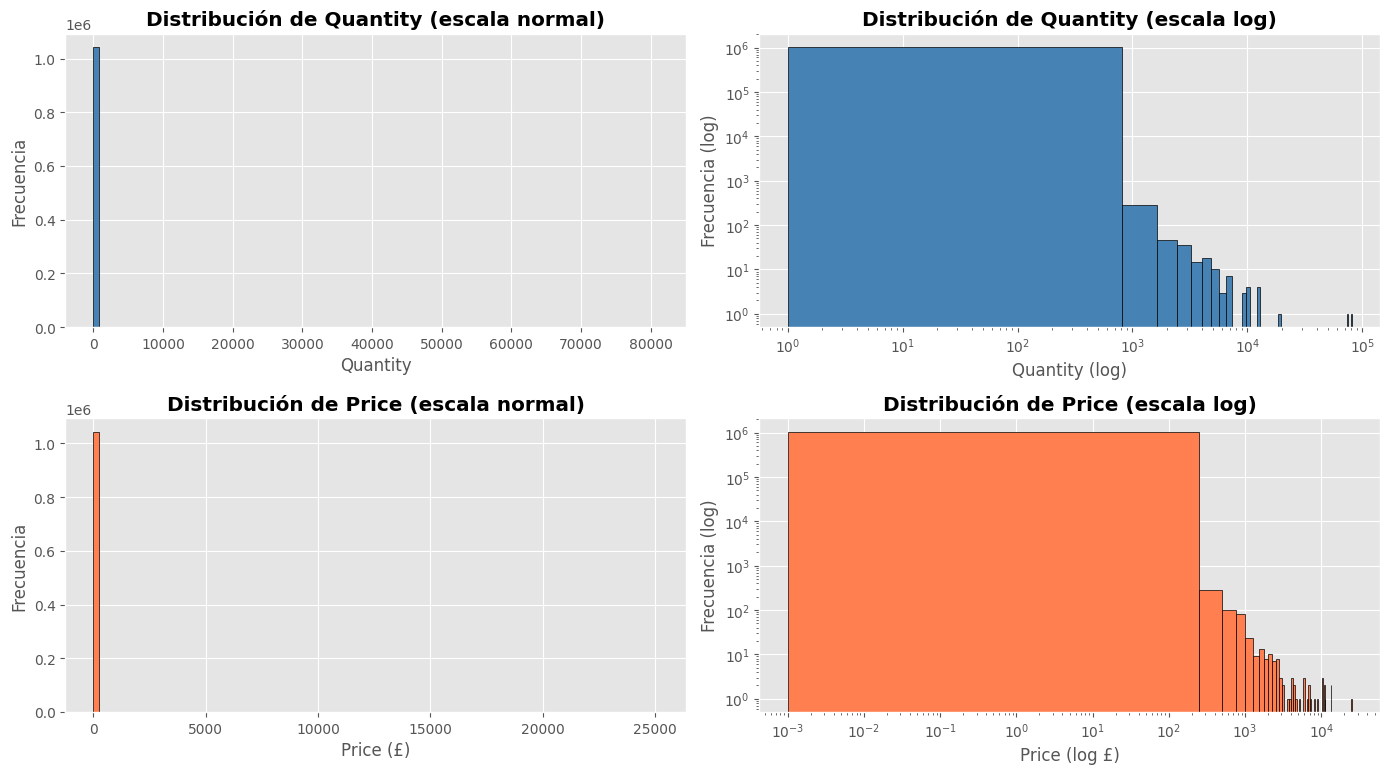

Cuantiles de Quantity (filtrado positivo):
0.50     3.00
0.90    24.00
0.95    30.00
0.99   100.00
1.00   485.98
Name: Quantity, dtype: float64

Cuantiles de Price (filtrado positivo):
0.50     2.10
0.90     7.95
0.95     9.95
0.99    18.00
1.00   159.28
Name: Price, dtype: float64


In [19]:
# ---- Distribución de Quantity y Price (con escala log) ----
df_pos = df.loc[(df['Quantity'] > 0) & (df['Price'] > 0)].copy()

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Quantity - escala normal
axes[0, 0].hist(df_pos['Quantity'], bins=100, color='steelblue', edgecolor='black')
axes[0, 0].set_title('Distribución de Quantity (escala normal)', fontweight='bold')
axes[0, 0].set_xlabel('Quantity')
axes[0, 0].set_ylabel('Frecuencia')

# Quantity - escala log
axes[0, 1].hist(df_pos['Quantity'], bins=100, color='steelblue', edgecolor='black')
axes[0, 1].set_yscale('log')
axes[0, 1].set_xscale('log')
axes[0, 1].set_title('Distribución de Quantity (escala log)', fontweight='bold')
axes[0, 1].set_xlabel('Quantity (log)')
axes[0, 1].set_ylabel('Frecuencia (log)')

# Price - escala normal
axes[1, 0].hist(df_pos['Price'], bins=100, color='coral', edgecolor='black')
axes[1, 0].set_title('Distribución de Price (escala normal)', fontweight='bold')
axes[1, 0].set_xlabel('Price (£)')
axes[1, 0].set_ylabel('Frecuencia')

# Price - escala log
axes[1, 1].hist(df_pos['Price'], bins=100, color='coral', edgecolor='black')
axes[1, 1].set_yscale('log')
axes[1, 1].set_xscale('log')
axes[1, 1].set_title('Distribución de Price (escala log)', fontweight='bold')
axes[1, 1].set_xlabel('Price (log £)')
axes[1, 1].set_ylabel('Frecuencia (log)')

plt.tight_layout()
plt.show()

# Cuantiles para entender el corte natural
print('Cuantiles de Quantity (filtrado positivo):')
print(df_pos['Quantity'].quantile([0.5, 0.9, 0.95, 0.99, 0.999]))
print('\nCuantiles de Price (filtrado positivo):')
print(df_pos['Price'].quantile([0.5, 0.9, 0.95, 0.99, 0.999]))

In [20]:
## Visualización 3: Top países

Top 15 países por revenue:
                 n_lineas  n_clientes       revenue
Country                                            
United Kingdom     981330        5410 16,382,583.90
EIRE                17866           5    615,519.55
Netherlands          5140          23    548,524.95
Germany             17624         107    417,988.56
France              14330          95    328,191.80
Australia            1913          15    167,129.07
Switzerland          3189          22     99,728.76
Spain                3811          41     91,859.48
Sweden               1364          19     87,809.42
Denmark               817          12     65,741.09
Belgium              3123          29     63,574.49
Portugal             2620          24     53,136.80
Japan                 582          10     43,776.58
Channel Islands      1664          14     41,453.61
Norway               1455          13     39,243.03


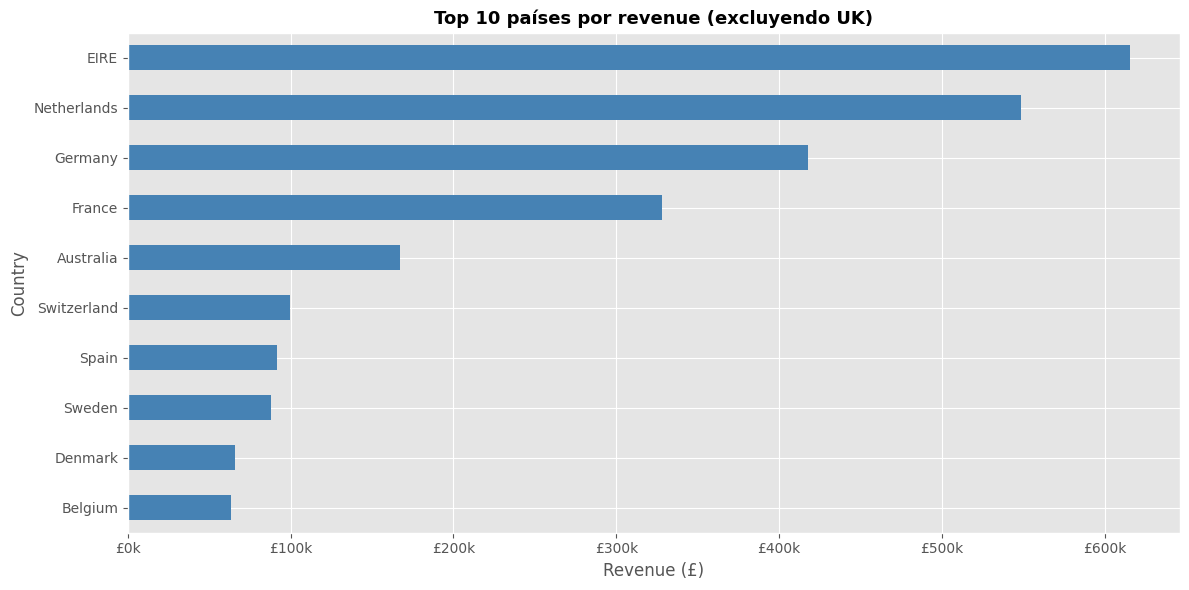


% de revenue de UK: 84.9%


In [21]:
# ---- Top países ----
top_paises = df.groupby('Country').agg(
    n_lineas=('Invoice', 'count'),
    n_clientes=('Customer ID', 'nunique'),
    revenue=('Revenue', 'sum')
).sort_values('revenue', ascending=False)

print('Top 15 países por revenue:')
print(top_paises.head(15))

# Gráfica: top países SIN UK (para que se vean los demás)
fig, ax = plt.subplots(figsize=(12, 6))
top_paises_sin_uk = top_paises.drop('United Kingdom').head(10)
top_paises_sin_uk['revenue'].plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Top 10 países por revenue (excluyendo UK)', fontsize=13, fontweight='bold')
ax.set_xlabel('Revenue (£)')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'£{x/1e3:.0f}k'))
ax.invert_yaxis()
plt.tight_layout()
plt.show()

# % UK vs resto
pct_uk = top_paises.loc['United Kingdom', 'revenue'] / top_paises['revenue'].sum() * 100
print(f'\n% de revenue de UK: {pct_uk:.1f}%')

## Visualización 4: Análisis por cliente

Total de clientes únicos: 5,878

Distribución de nº facturas por cliente:
count   5,878.00
mean        6.29
std        13.01
min         1.00
25%         1.00
50%         3.00
75%         7.00
max       398.00
Name: n_facturas, dtype: float64

Distribución de revenue total por cliente:
count     5,878.00
mean      3,018.62
std      14,737.73
min           2.95
25%         348.76
50%         898.91
75%       2,307.09
max     608,821.65
Name: revenue_total, dtype: float64

Distribución del ticket medio:
count    5,878.00
mean       391.73
std      1,215.07
min          2.95
25%        181.65
50%        285.07
75%        420.57
max     84,236.25
Name: ticket_medio, dtype: float64


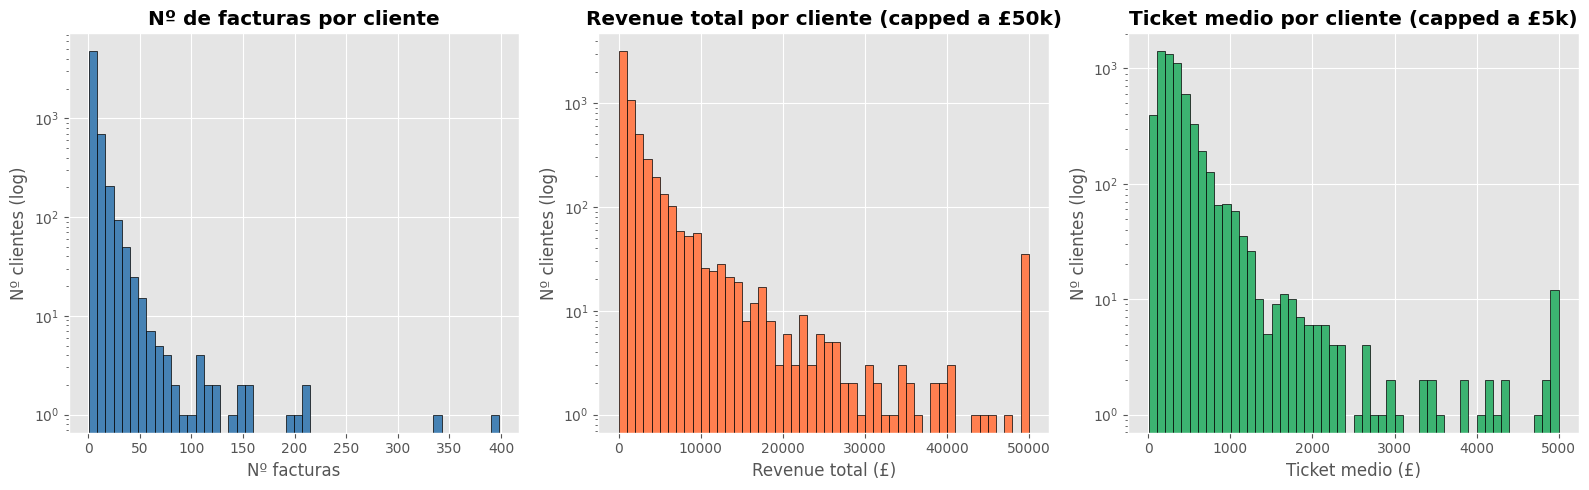

In [22]:
# ---- Análisis por cliente ----
df_clientes_eda = df.loc[
    (~df['is_cancellation']) & 
    (df['Customer ID'].notna()) & 
    (df['Quantity'] > 0) & 
    (df['Price'] > 0)
].copy()

clientes_resumen = df_clientes_eda.groupby('Customer ID').agg(
    n_facturas=('Invoice', 'nunique'),
    revenue_total=('Revenue', 'sum'),
    primera_compra=('InvoiceDate', 'min'),
    ultima_compra=('InvoiceDate', 'max')
)
clientes_resumen['ticket_medio'] = clientes_resumen['revenue_total'] / clientes_resumen['n_facturas']

print(f'Total de clientes únicos: {len(clientes_resumen):,}')
print(f'\nDistribución de nº facturas por cliente:')
print(clientes_resumen['n_facturas'].describe())
print(f'\nDistribución de revenue total por cliente:')
print(clientes_resumen['revenue_total'].describe())
print(f'\nDistribución del ticket medio:')
print(clientes_resumen['ticket_medio'].describe())

# Gráficas
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Histograma nº facturas (log)
axes[0].hist(clientes_resumen['n_facturas'], bins=50, color='steelblue', edgecolor='black')
axes[0].set_yscale('log')
axes[0].set_title('Nº de facturas por cliente', fontweight='bold')
axes[0].set_xlabel('Nº facturas')
axes[0].set_ylabel('Nº clientes (log)')

# Histograma revenue total (log)
axes[1].hist(clientes_resumen['revenue_total'].clip(upper=50000), bins=50, color='coral', edgecolor='black')
axes[1].set_yscale('log')
axes[1].set_title('Revenue total por cliente (capped a £50k)', fontweight='bold')
axes[1].set_xlabel('Revenue total (£)')
axes[1].set_ylabel('Nº clientes (log)')

# Histograma ticket medio (log)
axes[2].hist(clientes_resumen['ticket_medio'].clip(upper=5000), bins=50, color='mediumseagreen', edgecolor='black')
axes[2].set_yscale('log')
axes[2].set_title('Ticket medio por cliente (capped a £5k)', fontweight='bold')
axes[2].set_xlabel('Ticket medio (£)')
axes[2].set_ylabel('Nº clientes (log)')

plt.tight_layout()
plt.show()

## 2.4 Resumen del EDA y decisiones para la limpieza

### Hallazgos clave
- **1.067.371 transacciones** registradas entre dic-2009 y dic-2011 (24 meses).
- **5.878 clientes únicos identificados**. UK representa el 85% del revenue.
- **Estacionalidad fuerte** con pico en sept-nov (campaña B2B previa a Navidad).
- **Distribución muy sesgada**: el 25% de los clientes son one-time buyers; un solo cliente factura más de £600k.
- **Calidad de datos**: 22.7% de filas sin Customer ID, 3.2% duplicados, 1.8% cancelaciones, y existen ajustes contables ocultos como transacciones.

### Decisiones para la limpieza
1. Eliminar filas sin Customer ID (243k filas).
2. Eliminar duplicados exactos (34k filas).
3. Eliminar cancelaciones (Invoice empieza por 'C').
4. Eliminar StockCodes no-producto (POST, BANK CHARGES, ADJUST, D, M, etc.).
5. Filtrar Price > 0 y Quantity > 0.
6. Recortar outliers extremos (Quantity ≤ 100, Price ≤ 50; cuantil 99).
7. **Cutoff = 1 de junio de 2011**: 18 meses de histórico para features, 6 meses para target de recompra. 

## 3. Limpieza y preparación de datos

Aplicamos las decisiones tomadas en el EDA. Documentamos en cada paso 
cuántas filas se eliminan y por qué.

In [23]:
# ---- Punto de partida ----
df_limpio = df.copy()
n_inicial = len(df_limpio)
print(f'Filas iniciales: {n_inicial:,}')
print(f'\nLog de limpieza:')
log_limpieza = []
log_limpieza.append(('Inicial', n_inicial, 0, 0.0))

Filas iniciales: 1,067,371

Log de limpieza:


In [24]:
# ---- Filtro 1: Eliminar filas sin Customer ID ----
n_antes = len(df_limpio)
df_limpio = df_limpio.dropna(subset=['Customer ID'])
n_perdidas = n_antes - len(df_limpio)
log_limpieza.append(('Sin Customer ID', len(df_limpio), n_perdidas, n_perdidas/n_inicial*100))
print(f'1. Sin Customer ID:        -{n_perdidas:>7,}  →  {len(df_limpio):>9,}')

# ---- Filtro 2: Eliminar duplicados exactos ----
n_antes = len(df_limpio)
df_limpio = df_limpio.drop_duplicates()
n_perdidas = n_antes - len(df_limpio)
log_limpieza.append(('Duplicados', len(df_limpio), n_perdidas, n_perdidas/n_inicial*100))
print(f'2. Duplicados exactos:     -{n_perdidas:>7,}  →  {len(df_limpio):>9,}')

# ---- Filtro 3: Eliminar cancelaciones ----
n_antes = len(df_limpio)
df_limpio = df_limpio[~df_limpio['Invoice'].astype(str).str.startswith('C')]
n_perdidas = n_antes - len(df_limpio)
log_limpieza.append(('Cancelaciones', len(df_limpio), n_perdidas, n_perdidas/n_inicial*100))
print(f'3. Cancelaciones (Inv "C"): -{n_perdidas:>7,}  →  {len(df_limpio):>9,}')

# ---- Filtro 4: Eliminar StockCodes no-producto ----
codigos_excluir = ['POST', 'DOT', 'D', 'M', 'm', 'C2', 'C3', 'BANK CHARGES',
                   'AMAZONFEE', 'B', 'CRUK', 'ADJUST', 'ADJUST2', 'TEST', 'PADS']
n_antes = len(df_limpio)
df_limpio = df_limpio[~df_limpio['StockCode'].astype(str).isin(codigos_excluir)]
# También quitamos los gift_vouchers
df_limpio = df_limpio[~df_limpio['StockCode'].astype(str).str.startswith('gift_')]
n_perdidas = n_antes - len(df_limpio)
log_limpieza.append(('StockCodes no-producto', len(df_limpio), n_perdidas, n_perdidas/n_inicial*100))
print(f'4. StockCodes no-producto: -{n_perdidas:>7,}  →  {len(df_limpio):>9,}')

# ---- Filtro 5: Price y Quantity positivos ----
n_antes = len(df_limpio)
df_limpio = df_limpio[(df_limpio['Price'] > 0) & (df_limpio['Quantity'] > 0)]
n_perdidas = n_antes - len(df_limpio)
log_limpieza.append(('Price/Quantity ≤ 0', len(df_limpio), n_perdidas, n_perdidas/n_inicial*100))
print(f'5. Price/Quantity ≤ 0:     -{n_perdidas:>7,}  →  {len(df_limpio):>9,}')

# ---- Filtro 6: Outliers extremos (cuantil 99) ----
n_antes = len(df_limpio)
df_limpio = df_limpio[(df_limpio['Quantity'] <= 100) & (df_limpio['Price'] <= 50)]
n_perdidas = n_antes - len(df_limpio)
log_limpieza.append(('Outliers (Q>100 o P>50)', len(df_limpio), n_perdidas, n_perdidas/n_inicial*100))
print(f'6. Outliers extremos:      -{n_perdidas:>7,}  →  {len(df_limpio):>9,}')

print(f'\n{"="*60}')
print(f'Filas finales: {len(df_limpio):,}')
print(f'Filas eliminadas: {n_inicial - len(df_limpio):,} ({(n_inicial - len(df_limpio))/n_inicial*100:.1f}%)')
print(f'Filas conservadas: {len(df_limpio)/n_inicial*100:.1f}%')

1. Sin Customer ID:        -243,007  →    824,364
2. Duplicados exactos:     - 26,479  →    797,885
3. Cancelaciones (Inv "C"): - 18,390  →    779,495
4. StockCodes no-producto: -  2,844  →    776,651
5. Price/Quantity ≤ 0:     -     62  →    776,589
6. Outliers extremos:      - 10,102  →    766,487

Filas finales: 766,487
Filas eliminadas: 300,884 (28.2%)
Filas conservadas: 71.8%


In [25]:
# ---- Tabla resumen ----
log_df = pd.DataFrame(log_limpieza, columns=['Paso', 'Filas restantes', 'Filas eliminadas', '% acumulado'])
log_df

,Paso,Filas restantes,Filas eliminadas,% acumulado
0,Inicial,1067371,0,0.00
1,Sin Customer ID,824364,243007,22.77
2,Duplicados,797885,26479,2.48
3,Cancelaciones,779495,18390,1.72
4,StockCodes no-producto,776651,2844,0.27
5,Price/Quantity ≤ 0,776589,62,0.01
6,Outliers (Q>100 o P>50),766487,10102,0.95


In [26]:
# ---- Recalcular Revenue sobre el dataset limpio ----
df_limpio['Revenue'] = df_limpio['Quantity'] * df_limpio['Price']

# Tipo correcto para Customer ID (entero)
df_limpio['Customer ID'] = df_limpio['Customer ID'].astype(int)

# Comprobaciones
print(f'Clientes únicos: {df_limpio["Customer ID"].nunique():,}')
print(f'Facturas únicas: {df_limpio["Invoice"].nunique():,}')
print(f'Productos únicos: {df_limpio["StockCode"].nunique():,}')
print(f'Países únicos: {df_limpio["Country"].nunique()}')
print(f'\nRevenue total limpio: £{df_limpio["Revenue"].sum():,.0f}')
print(f'Rango temporal: {df_limpio["InvoiceDate"].min()} a {df_limpio["InvoiceDate"].max()}')
print(f'\nNulos restantes:')
print(df_limpio.isnull().sum())

Clientes únicos: 5,802
Facturas únicas: 35,687
Productos únicos: 4,601
Países únicos: 41

Revenue total limpio: £13,592,945
Rango temporal: 2009-12-01 07:45:00 a 2011-12-09 12:50:00

Nulos restantes:
Invoice            0
StockCode          0
Description        0
Quantity           0
InvoiceDate        0
Price              0
Customer ID        0
Country            0
is_cancellation    0
Revenue            0
dtype: int64


In [27]:
# ---- Guardar dataset limpio en pickle (para futuras sesiones) ----
df_limpio.to_pickle('online_retail_limpio.pkl')
print('Dataset limpio guardado en online_retail_limpio.pkl')
df_limpio.head()

Dataset limpio guardado en online_retail_limpio.pkl


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,is_cancellation,Revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,False,83.40
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,False,81.00
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,False,81.00
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,False,100.80
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,False,30.00


## 4. Construcción del dataset cliente

Pasamos de un dataset de transacciones (~766k filas) a un dataset de clientes
(5.802 filas), donde cada cliente tiene:

- **Features pre-cutoff** (1-dic-2009 a 31-may-2011): variables RFM y derivadas
  que describen el comportamiento histórico del cliente.
- **Target post-cutoff** (1-jun-2011 a 9-dic-2011): 1 si el cliente realizó al 
  menos una compra después del cutoff, 0 si no.

In [28]:
# ---- Definir cutoff y separar pasado/futuro ----
CUTOFF_DATE = pd.Timestamp('2011-06-01')

df_pasado = df_limpio[df_limpio['InvoiceDate'] < CUTOFF_DATE].copy()
df_futuro = df_limpio[df_limpio['InvoiceDate'] >= CUTOFF_DATE].copy()

print(f'Cutoff: {CUTOFF_DATE.date()}')
print(f'Filas pasado:  {len(df_pasado):,}')
print(f'Filas futuro:  {len(df_futuro):,}')
print(f'Clientes pasado:  {df_pasado["Customer ID"].nunique():,}')
print(f'Clientes futuro:  {df_futuro["Customer ID"].nunique():,}')

Cutoff: 2011-06-01
Filas pasado:  521,458
Filas futuro:  245,029
Clientes pasado:  4,864
Clientes futuro:  3,508


In [29]:
# ---- Construir features por cliente (a partir de df_pasado) ----

# Recencia, frecuencia, monetary, ticket medio
clientes = df_pasado.groupby('Customer ID').agg(
    last_purchase=('InvoiceDate', 'max'),
    first_purchase=('InvoiceDate', 'min'),
    frequency=('Invoice', 'nunique'),
    monetary=('Revenue', 'sum'),
    n_products=('StockCode', 'nunique'),
    n_items=('Quantity', 'sum'),
    n_lineas=('Invoice', 'count'),
    country=('Country', 'first')
)

# Derivadas
clientes['recency_days'] = (CUTOFF_DATE - clientes['last_purchase']).dt.days
clientes['tenure_days'] = (CUTOFF_DATE - clientes['first_purchase']).dt.days
clientes['avg_ticket'] = clientes['monetary'] / clientes['frequency']
clientes['avg_basket_size'] = clientes['n_lineas'] / clientes['frequency']

# Variable país: is_uk
clientes['is_uk'] = (clientes['country'] == 'United Kingdom').astype(int)

# % de compras en Q4 (octubre-diciembre) del pasado
df_pasado_q4 = df_pasado.copy()
df_pasado_q4['is_q4'] = df_pasado_q4['InvoiceDate'].dt.month.isin([10, 11, 12])
q4_facturas = df_pasado_q4.groupby('Customer ID').agg(
    facturas_q4=('Invoice', lambda x: x[df_pasado_q4.loc[x.index, 'is_q4']].nunique())
)
clientes = clientes.join(q4_facturas)
clientes['q4_share'] = clientes['facturas_q4'] / clientes['frequency']

# Limpiamos columnas auxiliares
clientes = clientes.drop(columns=['last_purchase', 'first_purchase', 'n_lineas', 'country', 'facturas_q4'])

print(f'Clientes con features: {len(clientes):,}')
print(f'\nFeatures construidas:')
print(clientes.columns.tolist())
print(f'\nResumen estadístico:')
clientes.describe()

Clientes con features: 4,864

Features construidas:
['frequency', 'monetary', 'n_products', 'n_items', 'recency_days', 'tenure_days', 'avg_ticket', 'avg_basket_size', 'is_uk', 'q4_share']

Resumen estadístico:


,frequency,monetary,n_products,n_items,recency_days,tenure_days,avg_ticket,avg_basket_size,is_uk,q4_share
count,"4,864.00","4,864.00","4,864.00","4,864.00","4,864.00","4,864.00","4,864.00","4,864.00","4,864.00","4,864.00"
mean,5.12,"1,924.49",70.47,"1,017.65",168.16,356.26,332.83,21.42,0.92,0.31
std,9.57,"5,695.35",96.75,"2,925.22",141.39,154.71,341.82,18.02,0.28,0.35
min,1.00,2.90,1.00,1.00,0.00,0.00,2.90,1.00,0.00,0.00
25%,1.00,305.59,17.00,152.75,43.00,231.00,168.58,9.85,1.00,0.00
50%,3.00,714.43,40.00,383.50,159.50,391.00,270.30,17.14,1.00,0.24
75%,6.00,"1,819.93",88.00,986.00,242.00,490.00,393.76,27.00,1.00,0.50
max,234.00,"173,307.14","1,967.00","91,345.00",546.00,546.00,"11,229.99",236.00,1.00,1.00


In [30]:
# ---- Construir el target ----
clientes_que_recompraron = df_futuro['Customer ID'].unique()
clientes['target_recompra'] = clientes.index.isin(clientes_que_recompraron).astype(int)

# Balance de clases
print('Distribución del target:')
print(clientes['target_recompra'].value_counts())
print(f'\n% que recompró: {clientes["target_recompra"].mean()*100:.1f}%')
print(f'% que NO recompró: {(1-clientes["target_recompra"].mean())*100:.1f}%')

Distribución del target:
target_recompra
1    2570
0    2294
Name: count, dtype: int64

% que recompró: 52.8%
% que NO recompró: 47.2%


In [31]:
# ---- Resumen final del dataset cliente ----
print(f'Dataset cliente final:')
print(f'  Filas (clientes): {len(clientes):,}')
print(f'  Columnas (features + target): {len(clientes.columns)}')
print(f'\nNulos:')
print(clientes.isnull().sum())

clientes.to_pickle('dataset_clientes.pkl')
print('\nGuardado en dataset_clientes.pkl')
clientes.head()

Dataset cliente final:
  Filas (clientes): 4,864
  Columnas (features + target): 11

Nulos:
frequency          0
monetary           0
n_products         0
n_items            0
recency_days       0
tenure_days        0
avg_ticket         0
avg_basket_size    0
is_uk              0
q4_share           0
target_recompra    0
dtype: int64

Guardado en dataset_clientes.pkl


,frequency,monetary,n_products,n_items,recency_days,tenure_days,avg_ticket,avg_basket_size,is_uk,q4_share,target_recompra
Customer ID,,,,,,,,,,,
12346,11,372.86,26,70,337,533,33.90,3.00,1,0.45,0
12347,4,"2,185.36",89,1386,54,212,546.34,30.75,0,0.50,1
12348,4,936.24,24,1144,56,246,234.06,8.50,0,0.25,1
12349,2,"2,221.14",89,991,215,397,"1,110.57",50.00,0,0.50,1
12350,1,294.40,16,196,118,118,294.40,16.00,0,0.00,0


## 5. Modelado

Entrenamos tres algoritmos para predecir la probabilidad de recompra y los
comparamos por AUC en un conjunto de test (20%).

In [32]:
# ---- Separar X (features) e y (target) ----
from sklearn.model_selection import train_test_split

X = clientes.drop(columns=['target_recompra'])
y = clientes['target_recompra']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y  # mantiene la proporción de clases
)

print(f'Train: {X_train.shape[0]:,} clientes ({y_train.mean()*100:.1f}% recompraron)')
print(f'Test:  {X_test.shape[0]:,} clientes ({y_test.mean()*100:.1f}% recompraron)')
print(f'\nFeatures que usaremos: {list(X.columns)}')

Train: 3,891 clientes (52.8% recompraron)
Test:  973 clientes (52.8% recompraron)

Features que usaremos: ['frequency', 'monetary', 'n_products', 'n_items', 'recency_days', 'tenure_days', 'avg_ticket', 'avg_basket_size', 'is_uk', 'q4_share']


In [36]:
# ---- Comparación de 3 algoritmos ----
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Para la regresión logística necesitamos escalar las features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 1. Regresión Logística (con datos escalados)
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)
lr_proba = lr.predict_proba(X_test_scaled)[:, 1]
lr_auc = roc_auc_score(y_test, lr_proba)

# 2. Random Forest
rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_proba = rf.predict_proba(X_test)[:, 1]
rf_auc = roc_auc_score(y_test, rf_proba)

# 3. LightGBM
lgbm = LGBMClassifier(n_estimators=200, random_state=42, verbose=-1)
lgbm.fit(X_train, y_train)
lgbm_proba = lgbm.predict_proba(X_test)[:, 1]
lgbm_auc = roc_auc_score(y_test, lgbm_proba)

# Resultados
print('=' * 50)
print(f'{"Modelo":<25}{"AUC":>10}')
print('=' * 50)
print(f'{"Regresión Logística":<25}{lr_auc:>10.4f}')
print(f'{"Random Forest":<25}{rf_auc:>10.4f}')
print(f'{"LightGBM":<25}{lgbm_auc:>10.4f}')
print('=' * 50)

Modelo                          AUC
Regresión Logística          0.7812
Random Forest                0.7646
LightGBM                     0.7585


### 5.2 Comparación inicial

Tres familias de modelos con configuración por defecto. La regresión logística
es la que mejor AUC obtiene de inicio (0.781), seguida de Random Forest (0.765) 
y LightGBM (0.759). El hecho de que el modelo lineal gane sugiere que el 
problema tiene una señal predominantemente lineal con las 10 features RFM.

### 5.3 Optimización de hiperparámetros

Tuneamos Random Forest y LightGBM con GridSearch para ver si, una vez 
optimizados, superan a la regresión logística.

In [37]:
# ---- Optimización de LightGBM con GridSearchCV ----
from sklearn.model_selection import GridSearchCV

param_grid_lgbm = {
    'n_estimators': [100, 200, 300],
    'max_depth': [-1, 5, 10],
    'learning_rate': [0.05, 0.1],
    'num_leaves': [15, 31, 63]
}

grid_lgbm = GridSearchCV(
    LGBMClassifier(random_state=42, verbose=-1),
    param_grid_lgbm,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_lgbm.fit(X_train, y_train)

print(f'Mejor AUC en CV: {grid_lgbm.best_score_:.4f}')
print(f'Mejores parámetros: {grid_lgbm.best_params_}')

# Evaluación en test
lgbm_best = grid_lgbm.best_estimator_
lgbm_best_proba = lgbm_best.predict_proba(X_test)[:, 1]
lgbm_best_auc = roc_auc_score(y_test, lgbm_best_proba)
print(f'AUC en test: {lgbm_best_auc:.4f}')

Fitting 5 folds for each of 54 candidates, totalling 270 fits
Mejor AUC en CV: 0.8105
Mejores parámetros: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 100, 'num_leaves': 15}
AUC en test: 0.7887


In [38]:
# ---- Optimización de Random Forest con GridSearchCV ----
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid_rf,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_rf.fit(X_train, y_train)

print(f'Mejor AUC en CV: {grid_rf.best_score_:.4f}')
print(f'Mejores parámetros: {grid_rf.best_params_}')

# Evaluación en test
rf_best = grid_rf.best_estimator_
rf_best_proba = rf_best.predict_proba(X_test)[:, 1]
rf_best_auc = roc_auc_score(y_test, rf_best_proba)
print(f'AUC en test: {rf_best_auc:.4f}')

Fitting 5 folds for each of 81 candidates, totalling 405 fits
Mejor AUC en CV: 0.8086
Mejores parámetros: {'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 100}
AUC en test: 0.7779


In [39]:
# ---- Tabla comparativa final de modelos ----
resultados = pd.DataFrame({
    'Modelo': ['Regresión Logística', 'Random Forest (default)', 'Random Forest (tuneado)', 
               'LightGBM (default)', 'LightGBM (tuneado)'],
    'AUC en test': [lr_auc, rf_auc, rf_best_auc, lgbm_auc, lgbm_best_auc]
})
resultados = resultados.sort_values('AUC en test', ascending=False).reset_index(drop=True)
print(resultados.to_string(index=False))

# El ganador
print(f'\n🏆 Modelo ganador: LightGBM tuneado (AUC = {lgbm_best_auc:.4f})')

                 Modelo  AUC en test
     LightGBM (tuneado)         0.79
    Regresión Logística         0.78
Random Forest (tuneado)         0.78
Random Forest (default)         0.76
     LightGBM (default)         0.76

🏆 Modelo ganador: LightGBM tuneado (AUC = 0.7887)


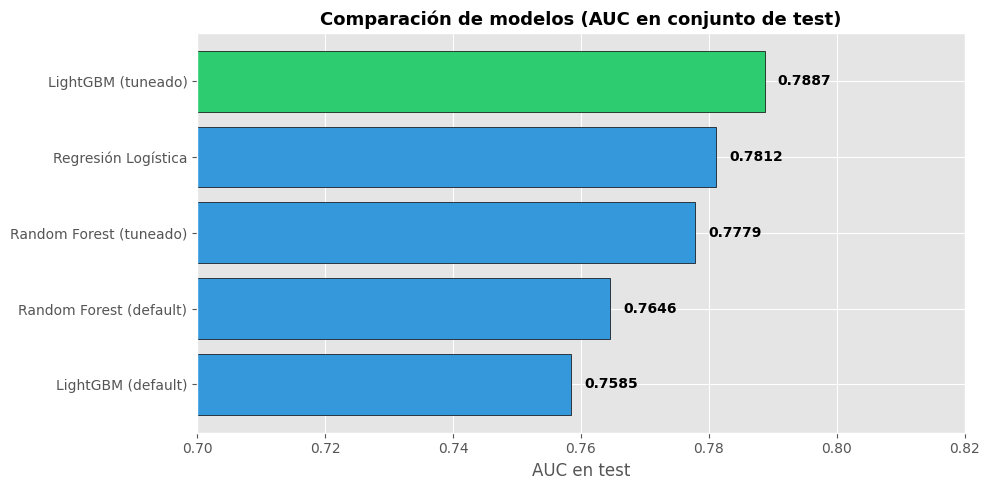

In [40]:
# ---- Gráfico comparativo ----
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#2ecc71' if v == resultados['AUC en test'].max() else '#3498db' 
          for v in resultados['AUC en test']]
bars = ax.barh(resultados['Modelo'], resultados['AUC en test'], color=colors, edgecolor='black')
ax.set_xlabel('AUC en test')
ax.set_title('Comparación de modelos (AUC en conjunto de test)', fontsize=13, fontweight='bold')
ax.set_xlim(0.70, 0.82)
ax.invert_yaxis()

# Etiquetas con el valor
for bar in bars:
    width = bar.get_width()
    ax.text(width + 0.002, bar.get_y() + bar.get_height()/2,
            f'{width:.4f}', va='center', fontsize=10, fontweight='bold')

# Línea base (modelo random = 0.5)
ax.axvline(0.5, color='gray', linestyle='--', alpha=0.5, label='Modelo aleatorio')

plt.tight_layout()
plt.show()

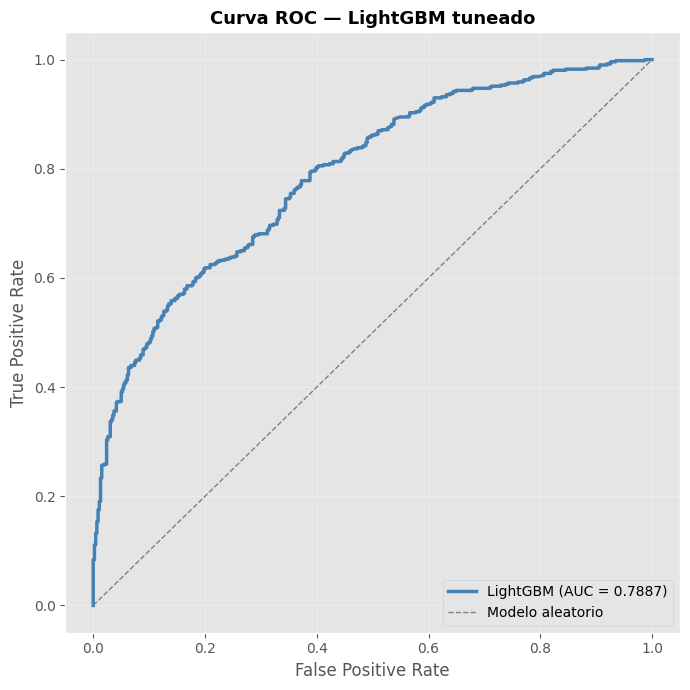

In [41]:
# ---- Curva ROC del modelo ganador ----
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, lgbm_best_proba)

fig, ax = plt.subplots(figsize=(7, 7))
ax.plot(fpr, tpr, color='steelblue', lw=2.5, label=f'LightGBM (AUC = {lgbm_best_auc:.4f})')
ax.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Modelo aleatorio')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Curva ROC — LightGBM tuneado', fontsize=13, fontweight='bold')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Explicabilidad

Analizamos qué features pesan más en las predicciones del modelo ganador 
(LightGBM tuneado) y comparamos con los coeficientes de la regresión logística
para validar la interpretación de negocio.

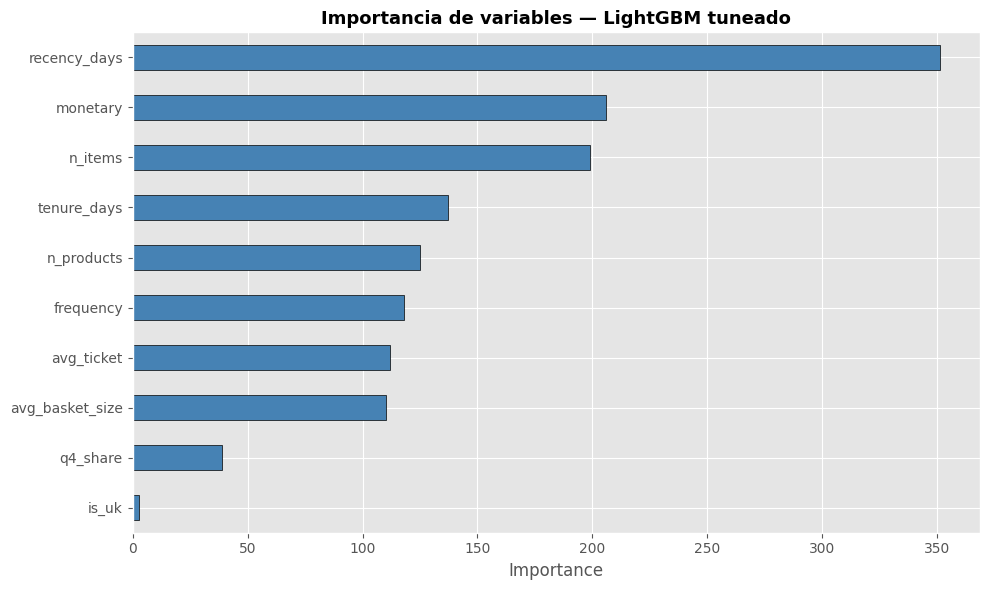

Ranking de importancia:
recency_days       351
monetary           206
n_items            199
tenure_days        137
n_products         125
frequency          118
avg_ticket         112
avg_basket_size    110
q4_share            39
is_uk                3
dtype: int32


In [42]:
# ---- Feature importance del LightGBM tuneado ----
importances_lgbm = pd.Series(
    lgbm_best.feature_importances_,
    index=X.columns
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
importances_lgbm.plot(kind='barh', color='steelblue', edgecolor='black', ax=ax)
ax.set_title('Importancia de variables — LightGBM tuneado', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

print('Ranking de importancia:')
print(importances_lgbm.sort_values(ascending=False))

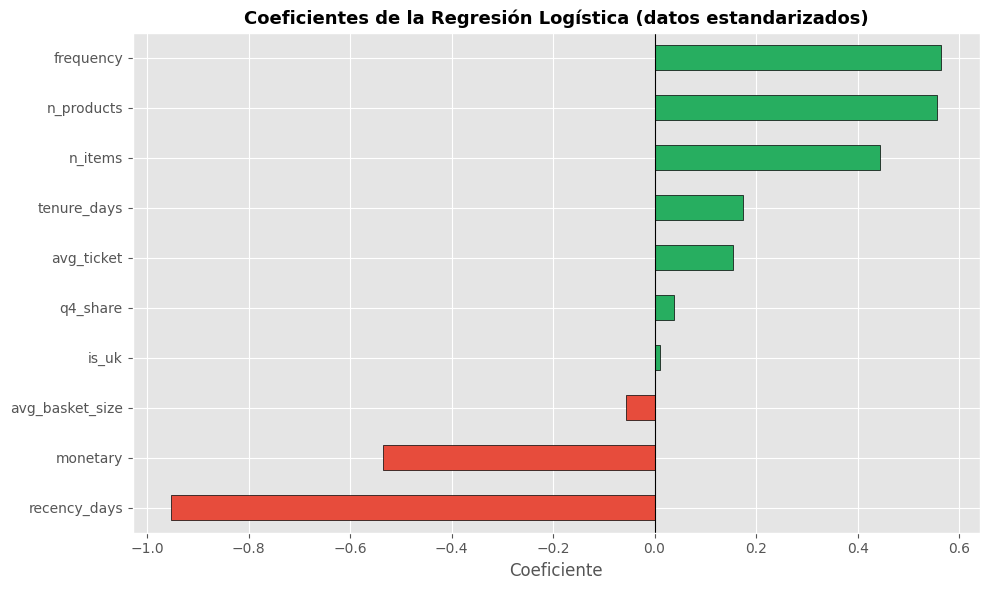

Coeficientes (positivo = aumenta probabilidad de recompra):
frequency          0.57
n_products         0.56
n_items            0.44
tenure_days        0.17
avg_ticket         0.15
q4_share           0.04
is_uk              0.01
avg_basket_size   -0.06
monetary          -0.54
recency_days      -0.95
dtype: float64


In [43]:
# ---- Coeficientes de la regresión logística ----
# Importante: la LR está entrenada con datos escalados, por lo que los coeficientes
# son comparables entre sí (mayor magnitud = más impacto en la probabilidad de recompra)

coef_lr = pd.Series(lr.coef_[0], index=X.columns).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#e74c3c' if v < 0 else '#27ae60' for v in coef_lr]
coef_lr.plot(kind='barh', color=colors, edgecolor='black', ax=ax)
ax.set_title('Coeficientes de la Regresión Logística (datos estandarizados)', fontsize=13, fontweight='bold')
ax.set_xlabel('Coeficiente')
ax.axvline(0, color='black', lw=0.8)
plt.tight_layout()
plt.show()

print('Coeficientes (positivo = aumenta probabilidad de recompra):')
print(coef_lr.sort_values(ascending=False))

### 6.3 Análisis SHAP del modelo ganador

Profundizamos en la explicabilidad del LightGBM tuneado con SHAP, que permite 
ver cómo cada feature contribuye a las predicciones individuales y al modelo 
en su conjunto.

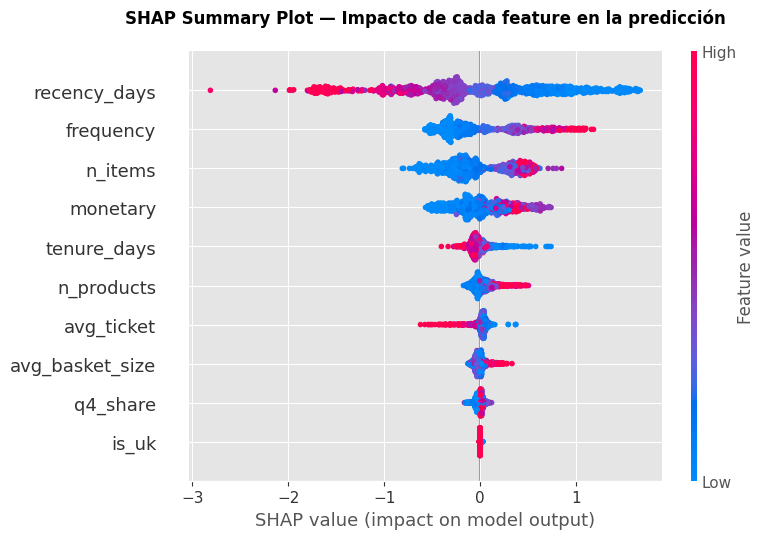

In [44]:
# ---- SHAP: análisis del modelo ganador (LightGBM tuneado) ----
import shap

# Crear el explainer para LightGBM
explainer = shap.TreeExplainer(lgbm_best)
shap_values = explainer.shap_values(X_test)

# En clasificación binaria, shap_values puede ser una lista [clase_0, clase_1] o un array.
# Nos quedamos con los de la clase positiva (recompra = 1)
if isinstance(shap_values, list):
    shap_values_plot = shap_values[1]
else:
    shap_values_plot = shap_values

# Summary plot (es la gráfica estrella)
shap.summary_plot(shap_values_plot, X_test, show=False)
plt.title('SHAP Summary Plot — Impacto de cada feature en la predicción', 
          fontsize=12, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

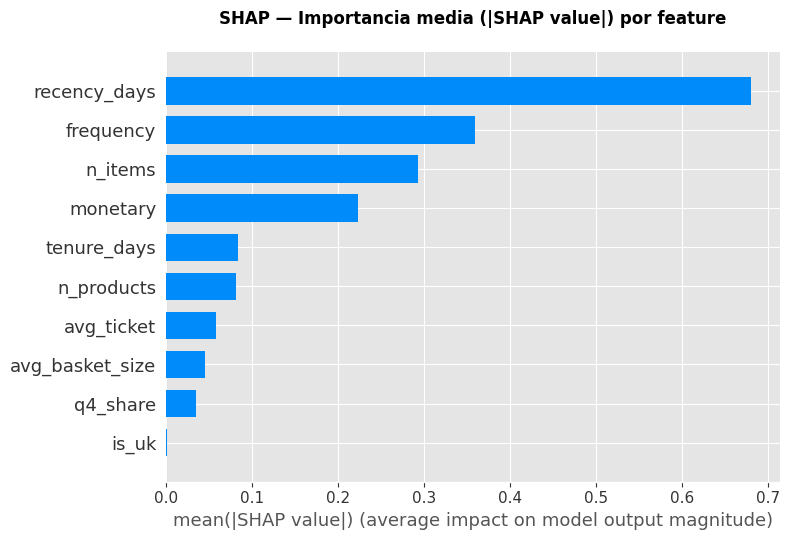

In [45]:
# ---- SHAP bar plot: importancia media absoluta ----
shap.summary_plot(shap_values_plot, X_test, plot_type='bar', show=False)
plt.title('SHAP — Importancia media (|SHAP value|) por feature',
          fontsize=12, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

In [46]:
# ---- Explicar dos clientes concretos: uno con alta y otro con baja probabilidad de recompra ----

# Predicciones del modelo
probs_test = lgbm_best.predict_proba(X_test)[:, 1]
X_test_with_proba = X_test.copy()
X_test_with_proba['prob_recompra'] = probs_test
X_test_with_proba['target_real'] = y_test.values

# Cliente con alta probabilidad
idx_alta = probs_test.argmax()
# Cliente con baja probabilidad
idx_baja = probs_test.argmin()

print(f'🟢 Cliente con ALTA probabilidad de recompra ({probs_test[idx_alta]*100:.1f}%):')
print(X_test.iloc[idx_alta])
print(f'\nTarget real: {"Recompró" if y_test.iloc[idx_alta] == 1 else "NO recompró"}')

print(f'\n{"="*60}\n')

print(f'🔴 Cliente con BAJA probabilidad de recompra ({probs_test[idx_baja]*100:.1f}%):')
print(X_test.iloc[idx_baja])
print(f'\nTarget real: {"Recompró" if y_test.iloc[idx_baja] == 1 else "NO recompró"}')

🟢 Cliente con ALTA probabilidad de recompra (98.5%):
frequency            18.00
monetary          4,511.90
n_products          372.00
n_items           2,541.00
recency_days          6.00
tenure_days         221.00
avg_ticket          250.66
avg_basket_size      55.50
is_uk                 1.00
q4_share              0.22
Name: 13263, dtype: float64

Target real: Recompró


🔴 Cliente con BAJA probabilidad de recompra (6.6%):
frequency           1.00
monetary           76.74
n_products          6.00
n_items            58.00
recency_days      497.00
tenure_days       497.00
avg_ticket         76.74
avg_basket_size     6.00
is_uk               1.00
q4_share            0.00
Name: 16867, dtype: float64

Target real: NO recompró



🟢 Desglose de la predicción para el cliente con MAYOR probabilidad:



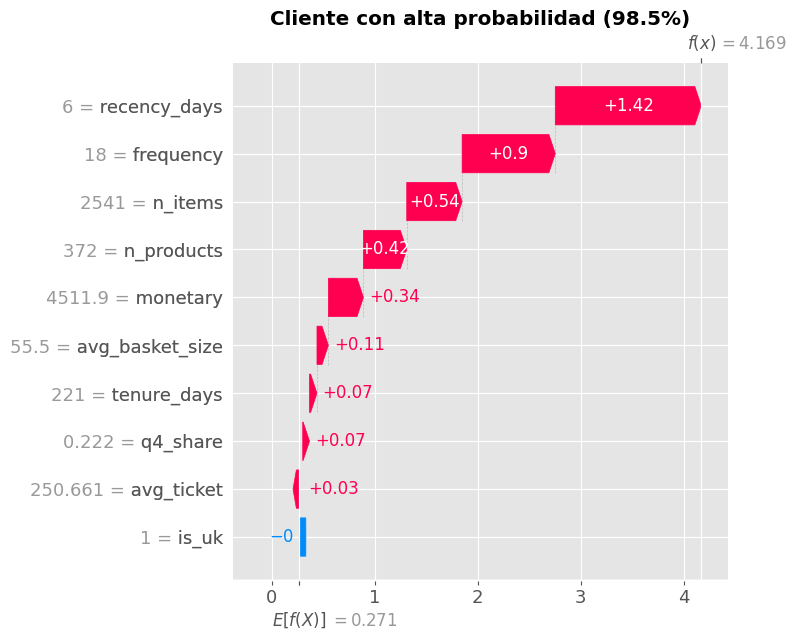


🔴 Desglose de la predicción para el cliente con MENOR probabilidad:



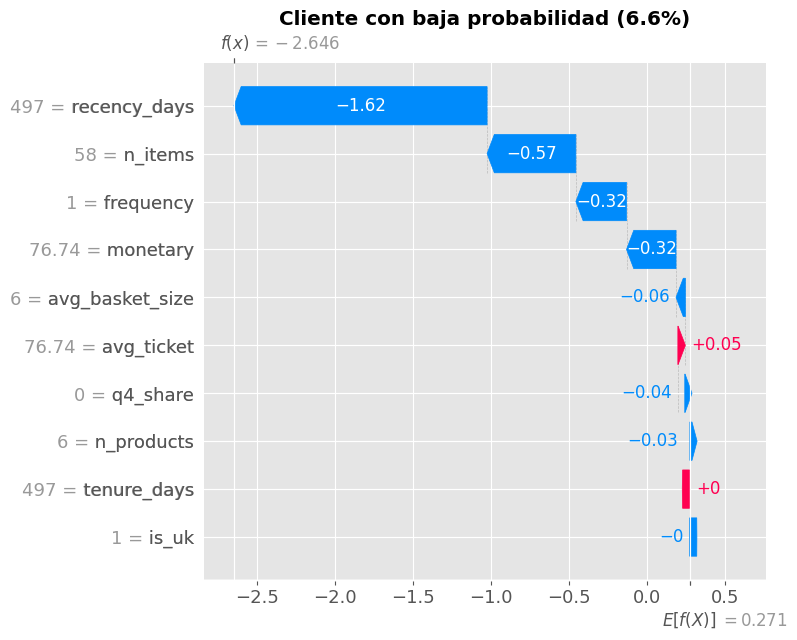

In [47]:
# ---- Waterfall plot para cliente con alta probabilidad ----
print('\n🟢 Desglose de la predicción para el cliente con MAYOR probabilidad:\n')
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values_plot[idx_alta],
        base_values=explainer.expected_value if not isinstance(explainer.expected_value, list) else explainer.expected_value[1],
        data=X_test.iloc[idx_alta].values,
        feature_names=X_test.columns.tolist()
    ),
    show=False
)
plt.title(f'Cliente con alta probabilidad ({probs_test[idx_alta]*100:.1f}%)',
          fontweight='bold')
plt.tight_layout()
plt.show()

# ---- Waterfall plot para cliente con baja probabilidad ----
print('\n🔴 Desglose de la predicción para el cliente con MENOR probabilidad:\n')
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values_plot[idx_baja],
        base_values=explainer.expected_value if not isinstance(explainer.expected_value, list) else explainer.expected_value[1],
        data=X_test.iloc[idx_baja].values,
        feature_names=X_test.columns.tolist()
    ),
    show=False
)
plt.title(f'Cliente con baja probabilidad ({probs_test[idx_baja]*100:.1f}%)',
          fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Conclusiones y propuesta de uso

### Resultados del modelo

- Se ha construido un modelo de **probabilidad de recompra** sobre 4.864 clientes 
  activos en los 18 meses anteriores al cutoff (1-jun-2011).
- El **modelo ganador es LightGBM tuneado** con un **AUC = 0.789** en el conjunto 
  de test, marginalmente por encima de la regresión logística (0.781).
- La señal del problema es **predominantemente lineal**: la regresión logística 
  sin tuning queda muy cerca del modelo más complejo, lo que es relevante si se 
  prioriza la interpretabilidad.

### Variables clave (por orden de importancia)

1. **Recency_days** — la variable dominante. Cuantos más días sin comprar, menos 
   probabilidad de recompra.
2. **Frequency, n_items, monetary** — describen el volumen de actividad histórica.
3. **Q4_share e is_uk** — aportan poco al modelo; se podrían retirar en una v2.

### Insight de negocio

> **Un cliente fiel no es el que más gasta, es el que más veces vuelve**.
> El coeficiente de `monetary` es negativo una vez se controla por `frequency`: 
> los clientes con monetary alto y frequency baja (mayoristas con pedidos puntuales 
> enormes) tienen ciclos largos y muchos no recompran en 6 meses.

### Propuesta de uso para el equipo comercial

| Segmento | % de clientes | Acción recomendada |
|---|---|---|
| **Alta probabilidad** (≥70%) | ~30% | **Fidelización**: programa VIP, ofertas exclusivas, gestor dedicado |
| **Media probabilidad** (30-70%) | ~40% | **Mantenimiento**: comunicación regular, descuentos puntuales |
| **Baja probabilidad** (<30%) | ~30% | **Retención agresiva**: descuento fuerte, campaña de reactivación |

### Limitaciones y próximos pasos

**Limitaciones detectadas:**
- 22.7% de las transacciones no tienen Customer ID (compradores anónimos) y se 
  perdieron del análisis.
- El cutoff elegido (1-jun-2011) cubre 6 meses de futuro que incluyen la campaña 
  de Navidad; con otra ventana los resultados podrían variar.
- Solo se han usado 10 features RFM; faltan variables que podrían enriquecer 
  el modelo.

**Próximos pasos propuestos:**
1. **Más features**: categoría de producto comprado, día de la semana favorito, 
   tendencia (¿está aumentando o disminuyendo su gasto?), velocidad de compra 
   (días entre facturas).
2. **Validación temporal**: probar diferentes cutoffs (3 meses, 12 meses) para 
   ver la robustez.
3. **Segmentación**: entrenar modelos separados para UK vs no-UK o para 
   mayoristas vs minoristas, ya que se han identificado dos perfiles de cliente 
   muy diferentes en el EDA.
4. **Modelos más avanzados**: catboost, redes neuronales tabulares.
5. **Calibración de probabilidades**: asegurar que un 80% predicho corresponde 
   realmente a un 80% de tasa de recompra observada.
6. **Monitorización**: implementar monitoring de la performance del modelo en 
   producción y reentrenamiento periódico.